## Part A — Trained Models (in a Jupyter Notebook or VS Code)


- Extract, design, and engineer new features from raw text (see the dataset on Canvas)
- Train and compare six models: 3 traditional ML models and 3 deep learning models
- Tune each model and evaluate performance with metrics and charts


In [92]:
import pandas as pd

df = pd.read_excel("../data/train_data_with_labels.xlsx")
df.head()

,text,label
0,Councils are debating if building housing area...,0
1,While reading the succesful people's lifes you...,0
2,"Finally, she felt that the robotics unit was i...",1
3,Since sigmoid can be viewed as a special 2clas...,1
4,In this essay we will talk about why in so man...,0


### Dataset Overview

The dataset contains text samples labeled as either Human-written or AI-written:

- **Label 0**: Human-written text
- **Label 1**: AI-written text

The dataset comprises 8,176 samples with two columns:
- `text`: The text content
- `label`: Binary classification (0 or 1)

### Data Investigation

In [93]:
# Check missing values in each column
df.isna().sum()

text     0
label    0
dtype: int64

In [94]:
counts = df['label'].value_counts().sort_index()
print(f"label 0: {counts.get(0, 0)}")
print(f"label 1: {counts.get(1, 0)}")

label 0: 4088
label 1: 4088



### Data Splitting

The dataset is balanced with 4,088 samples for each class (Human-written and AI-written). Next, we'll split the data into training and testing sets using an 80/20 split to prepare for model training and evaluation.

In [95]:
from sklearn.model_selection import train_test_split

X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 6540
Testing set size: 1636


In [99]:
X_test[5846]

'Ma et al. tried a bottomup linearization, but they obtained worse results than topdown approaches. 1 Liu and Zhang kept the topdown strategy, but using transitions of the topdown transition system of Dyer et al. instead of a bracketed linearization, achieving a higher performance. In transitionbased constituent parsing, an inorder algorithm has recently proved superior to the bottomup and topdown approaches, but we know of no applications of this approach in seq2seq parsing. Contributions In this paper, we advance the understanding of linearizations for seq2seq parsing, and improve the state of the art, as follows: (1) we show that the superiority of a transitionbased topdown linearization over a bracketingbased one observed by Liu and Zhang does not hold when both are tested under the same framework. In fact, we show that the additional information provided by the larger vocabulary in the linearization of Vinyals et al. is beneficial to seq2seq predictions. (2) We implement a novel i

### Step 1 — Feature Engineering
Before any model can make a prediction, you need to convert raw text into numbers the model can understand. This process is called feature engineering. You will
implement three types of features

#### 1A. TF-IDF (Term Frequency–Inverse Document Frequency)

TF-IDF is the recommended starting point. It is simple, fast, and works well with all six models.

**How it works in plain English:**
- Every word in the text gets a score.
- Words that appear often in one document but rarely across all documents get a high score, so they are considered distinctive.
- Common words like “the” or “and” get a low score because they are not informative.

The result is a large table of numbers, with one row per document and one column per word, that the classifiers can learn from.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000, #tuneable
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

In [ ]:
import joblib
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')
print("TF-IDF vectorizer saved to models/tfidf_vectorizer.pkl")

In [8]:
temp = X_train_tfidf[0].toarray()
print(temp)

In [9]:
X_train[0]

In [10]:
feature_names = tfidf.get_feature_names_out()
feature_names[-100:]

#### 1B. Word Embeddings (Choose at Least One)

Word embeddings represent words as dense vectors that capture meaning, not just frequency.  
Words with similar meanings end up with similar vector representations.

There are several options. Choose at least one and compare it with TF-IDF.

**BERT** is a state-of-the-art embedding model. It understands context, so the same word can have different meanings depending on usage:

- *river bank*
- *bank account*

In [11]:
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import DataLoader

model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
bert_model.to(device)
bert_model.eval()

def get_bert_embeddings(texts, batch_size=16, max_length=128):

    """
    Convert a list of texts into BERT embeddings using mean pooling.    
    
    """

    texts = texts.astype(str).tolist() if hasattr(texts, "astype") else list(map(str, texts))
    loader = DataLoader(texts, batch_size=batch_size, shuffle=False)
    embeddings = []

    with torch.no_grad():
        for batch_texts in loader:
            encoded = tokenizer(
                list(batch_texts),
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            ).to(device)

            outputs = bert_model(**encoded)
            last_hidden = outputs.last_hidden_state
            attention_mask = encoded["attention_mask"].unsqueeze(-1)

            mean_pooled = (last_hidden * attention_mask).sum(dim=1) / attention_mask.sum(dim=1).clamp(min=1)
            embeddings.append(mean_pooled.cpu().numpy())

    return np.vstack(embeddings)

X_train_bert = get_bert_embeddings(X_train)
X_test_bert = get_bert_embeddings(X_test)

print("BERT train shape:", X_train_bert.shape)
print("BERT test shape:", X_test_bert.shape)

In [12]:
X_train_bert[0]

In [13]:
X_train[0]

### Step 2 — Model Development
You will train six classifiers. Three are traditional machine learning models; three
are deep learning models. This lets you directly compare the two approaches on the
same task.

#### A. Traditional Machine Learning Models

#### ML Model 1 — Support Vector Machine (SVM)
What it does: Draws the best possible boundary between AI-written and human-
written text.
Why it works here: SVM performs very well on high-dimensional text data like
TF-IDF vectors.
Hyperparameters to tune: C (controls how strict the boundary is), kernel
(linear or RBF).
Tuning tool: Use GridSearchCV from scikit-learn.

In [18]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

param_grid = {
    'C': [0.1, 1, 10, 100],
    'tol': [1e-3, 1e-4, 1e-5]
}

svm_model = LinearSVC(random_state=42, max_iter=2000)
grid_search = GridSearchCV(svm_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_tfidf, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

svm_model = grid_search.best_estimator_
y_pred_svm = svm_model.predict(X_test_tfidf)

print("\nAccuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

# ROC curve (use decision scores for LinearSVC)
y_score_svm = svm_model.decision_function(X_test_tfidf)
fpr, tpr, _ = roc_curve(y_test, y_score_svm)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"SVM (BERT) AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LinearSVC with tfidf Embeddings")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
import joblib
joblib.dump(svm_model, '../models/svm_model_tfidf.pkl')
print("SVM (TF-IDF) model saved to models/svm_model_tfidf.pkl")

In [17]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

svm_model_bert = LinearSVC(random_state=42)
svm_model_bert.fit(X_train_bert, y_train)

y_pred_svm_bert = svm_model_bert.predict(X_test_bert)

print("Accuracy:", accuracy_score(y_test, y_pred_svm_bert))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm_bert))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm_bert))

# ROC curve (use decision scores for LinearSVC)
y_score_svm_bert = svm_model_bert.decision_function(X_test_bert)
fpr, tpr, _ = roc_curve(y_test, y_score_svm_bert)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"SVM (BERT) AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LinearSVC with BERT Embeddings")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
joblib.dump(svm_model_bert, '../models/svm_model_bert.pkl')
print("SVM (BERT) model saved to models/svm_model_bert.pkl")

In [16]:
svm_model_bert

In [17]:
y_pred_svm_bert[:10]

In [18]:
y_test[:10]

#### ML Model 2 — Decision Tree

What it does: Learns a series of yes/no questions to classify text (e.g., "Is average sentence length > 20?").

Why it works here: Produces explainable rules — great for understanding which patterns reveal AI-written text.

Hyperparameters to tune: `max_depth` (how many questions deep), `min_samples_split`.

Bonus: You can visualize the trained decision tree.

In [19]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42, max_depth=20, min_samples_split=5)
dt_model.fit(X_train_tfidf, y_train)

y_pred_dt = dt_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

# ROC + AUC (Decision Tree supports predict_proba)
y_score_dt = dt_model.predict_proba(X_test_tfidf)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_score_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(6, 5))
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (TF-IDF) AUC = {roc_auc_dt:.4f}")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree with TF-IDF")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
joblib.dump(dt_model, '../models/decision_tree_model_tfidf.pkl')
print("Decision Tree (TF-IDF) model saved to models/decision_tree_model_tfidf.pkl")

In [20]:
from sklearn import tree

import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10), dpi=150)
tree.plot_tree(
    dt_model,
    max_depth=3,  # adjust for more/less detail
    feature_names=feature_names,
    class_names=['human', 'ai'],
    filled=True,
    fontsize=8,
)
plt.title("Decision Tree (top 3 levels)")
plt.show()

In [20]:
dt_model_bert = DecisionTreeClassifier(random_state=42, max_depth=20, min_samples_split=5)
dt_model_bert.fit(X_train_bert, y_train)

y_pred_dt_bert = dt_model_bert.predict(X_test_bert)

print("Accuracy:", accuracy_score(y_test, y_pred_dt_bert))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt_bert))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt_bert))

y_score_dt_bert = dt_model_bert.predict_proba(X_test_bert)[:, 1]
fpr_dt_bert, tpr_dt_bert, _ = roc_curve(y_test, y_score_dt_bert)
roc_auc_dt_bert = auc(fpr_dt_bert, tpr_dt_bert)

plt.figure(figsize=(6, 5))
plt.plot(fpr_dt_bert, tpr_dt_bert, label=f"Decision Tree (BERT) AUC = {roc_auc_dt_bert:.4f}")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree with BERT Embeddings")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
joblib.dump(dt_model_bert, '../models/decision_tree_model_bert.pkl')
print("Decision Tree (BERT) model saved to models/decision_tree_model_bert.pkl")

In [22]:
from sklearn import tree

import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10), dpi=150)
tree.plot_tree(
    dt_model_bert,
    max_depth=3,
    class_names=['human', 'ai'],
    filled=True,
    fontsize=8,
)
plt.title("Decision Tree with BERT Embeddings (top 3 levels)")
plt.show()

In [21]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

ada_model_tfidf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=100,
    random_state=42
)
ada_model_tfidf.fit(X_train_tfidf, y_train)

y_pred_ada = ada_model_tfidf.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_ada))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ada))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_ada))

y_score_ada = ada_model_tfidf.predict_proba(X_test_tfidf)[:, 1]
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_score_ada)
roc_auc_ada = auc(fpr_ada, tpr_ada)

plt.figure(figsize=(6, 5))
plt.plot(fpr_ada, tpr_ada, label=f"AdaBoost (TF-IDF) AUC = {roc_auc_ada:.4f}")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - AdaBoost with TF-IDF")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
joblib.dump(ada_model_tfidf, '../models/adaboost_model_tfidf.pkl')
print("AdaBoost (TF-IDF) model saved to models/adaboost_model_tfidf.pkl")

In [22]:
# Train AdaBoost on BERT embeddings
ada_model_bert = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=100,
    random_state=42
)
ada_model_bert.fit(X_train_bert, y_train)

y_pred_ada_bert = ada_model_bert.predict(X_test_bert)

print("Accuracy:", accuracy_score(y_test, y_pred_ada_bert))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ada_bert))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_ada_bert))

# ROC curve and AUC
y_score_ada_bert = ada_model_bert.predict_proba(X_test_bert)[:, 1]
fpr_ada_bert, tpr_ada_bert, _ = roc_curve(y_test, y_score_ada_bert)
roc_auc_ada_bert = auc(fpr_ada_bert, tpr_ada_bert)

plt.figure(figsize=(6, 5))
plt.plot(fpr_ada_bert, tpr_ada_bert, label=f"AdaBoost (BERT) AUC = {roc_auc_ada_bert:.4f}")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - AdaBoost with BERT Embeddings")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
joblib.dump(ada_model_bert, '../models/adaboost_model_bert.pkl')
print("AdaBoost (BERT) model saved to models/adaboost_model_bert.pkl")

#### Deep Learning Models
These models learn representations directly from text and can capture patterns that
handcrafted features miss. They require more data and training time.

DL Model 1 — Feedforward Neural Network (FNN)
What it does: A classic multi-layer neural network. Input is a TF-IDF or
embedding vector.
Why start here: It is the simplest deep learning model and a good bridge
from ML to DL.
Key parameters: Number of hidden layers, neurons per layer, dropout rate.
Tip for beginners: Start with 2 hidden layers (128 neurons each) and add
dropout = 0.3.

In [25]:
from sklearn.neural_network import MLPClassifier

nn_param_grid = {
    "hidden_layer_sizes": [(128,), (128, 64)],
    "alpha": [1e-4, 1e-3],
    "learning_rate_init": [1e-3, 1e-4],
}

nn_model = MLPClassifier(
    random_state=42,
    max_iter=20,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=3,
)

nn_grid = GridSearchCV(
    nn_model,
    nn_param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

nn_grid.fit(X_train_tfidf, y_train)

print("Best parameters:", nn_grid.best_params_)
print("Best CV score:", nn_grid.best_score_)

nn_model = nn_grid.best_estimator_
y_pred_nn = nn_model.predict(X_test_tfidf)

print("\nAccuracy:", accuracy_score(y_test, y_pred_nn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nn))

# ROC curve + AUC for tuned MLP (TF-IDF)
y_score_nn = nn_model.predict_proba(X_test_tfidf)[:, 1]
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_score_nn)
roc_auc_nn = auc(fpr_nn, tpr_nn)

plt.figure(figsize=(6, 5))
plt.plot(fpr_nn, tpr_nn, label=f"MLP (TF-IDF) AUC = {roc_auc_nn:.4f}")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MLP with TF-IDF")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
import joblib
joblib.dump(nn_model, '../models/nn_model_tfidf.pkl')
print("MLP (TF-IDF) model saved to models/nn_model_tfidf.pkl")

In [26]:
nn_model_bert = MLPClassifier(
    random_state=42,
    max_iter=20,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=3,
)

nn_grid_bert = GridSearchCV(
    nn_model_bert,
    nn_param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

nn_grid_bert.fit(X_train_bert, y_train)

print("Best parameters:", nn_grid_bert.best_params_)
print("Best CV score:", nn_grid_bert.best_score_)

nn_model_bert = nn_grid_bert.best_estimator_
y_pred_nn_bert = nn_model_bert.predict(X_test_bert)

print("\nAccuracy:", accuracy_score(y_test, y_pred_nn_bert))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nn_bert))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nn_bert))

# ROC curve + AUC for tuned MLP (BERT)
y_score_nn_bert = nn_model_bert.predict_proba(X_test_bert)[:, 1]
fpr_nn_bert, tpr_nn_bert, _ = roc_curve(y_test, y_score_nn_bert)
roc_auc_nn_bert = auc(fpr_nn_bert, tpr_nn_bert)

plt.figure(figsize=(6, 5))
plt.plot(fpr_nn_bert, tpr_nn_bert, label=f"MLP (BERT) AUC = {roc_auc_nn_bert:.4f}")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MLP with BERT Embeddings")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
joblib.dump(nn_model_bert, '../models/nn_model_bert.pkl')
print("MLP (BERT) model saved to models/nn_model_bert.pkl")

#### DL Model 2 — LSTM (Long Short-Term Memory)

- **What it does:** A recurrent neural network that reads text sequentially and learns long-range dependencies.
- **Why it works here:** Word order and sentence structure can be important for detecting AI-generated text.
- **Key parameters:** Number of LSTM units, sequence length, embedding dimension.
- **Note:** Requires tokenized and padded sequences as input, not raw TF-IDF vectors.


In [27]:
import re
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

max_words = 20000
max_len = 200
batch_size = 64
epochs = 10
patience = 4

def simple_tokenize(text):
    text = str(text).lower()
    return re.findall(r"\b\w+\b", text)

# Build vocab from training text
counter = {}
for text in X_train.astype(str):
    for tok in simple_tokenize(text):
        counter[tok] = counter.get(tok, 0) + 1

vocab = {"<PAD>": 0, "<UNK>": 1}
for tok, _ in sorted(counter.items(), key=lambda x: x[1], reverse=True)[:max_words - 2]:
    vocab[tok] = len(vocab)

def encode_text(text):
    ids = [vocab.get(tok, vocab["<UNK>"]) for tok in simple_tokenize(text)]
    ids = ids[:max_len]
    ids += [vocab["<PAD>"]] * (max_len - len(ids))
    return ids

X_train_seq = torch.tensor([encode_text(t) for t in X_train.astype(str)], dtype=torch.long)
X_test_seq = torch.tensor([encode_text(t) for t in X_test.astype(str)], dtype=torch.long)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32)

# Validation split
n_val = int(0.1 * len(X_train_seq))
X_val_seq = X_train_seq[:n_val]
y_val_t = y_train_t[:n_val]
X_tr_seq = X_train_seq[n_val:]
y_tr_t = y_train_t[n_val:]

train_loader = DataLoader(TensorDataset(X_tr_seq, y_tr_t), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_seq, y_val_t), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_seq, y_test_t), batch_size=batch_size, shuffle=False)

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=64, num_layers=1, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        x = self.dropout(hidden[-1])
        return self.fc(x).squeeze(1)

lstm_model = LSTMClassifier(vocab_size=len(vocab)).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)

best_val_loss = float("inf")
best_state = None
wait = 0

for epoch in range(epochs):
    lstm_model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = lstm_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)

    lstm_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = lstm_model(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * xb.size(0)

    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)

    print(f"Epoch {epoch+1}/{epochs} - train loss: {train_loss:.4f} - val loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = lstm_model.state_dict()
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            break

if best_state is not None:
    lstm_model.load_state_dict(best_state)

# Evaluate
lstm_model.eval()
all_preds = []

with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        logits = lstm_model(xb)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).long().cpu().numpy()
        all_preds.extend(preds)

y_pred_lstm = np.array(all_preds)

print("Accuracy:", accuracy_score(y_test, y_pred_lstm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lstm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lstm))

# ROC curve for LSTM
lstm_model.eval()
all_probs = []

with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        logits = lstm_model(xb)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs)

y_score_lstm = np.array(all_probs)
fpr_lstm, tpr_lstm, _ = roc_curve(y_test, y_score_lstm)
roc_auc_lstm = auc(fpr_lstm, tpr_lstm)

print(f"LSTM ROC-AUC: {roc_auc_lstm:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(fpr_lstm, tpr_lstm, label=f"LSTM (AUC = {roc_auc_lstm:.4f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LSTM")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
import joblib
joblib.dump(lstm_model, '../models/lstm_model.pkl')
print("LSTM model saved to models/lstm_model.pkl")

#### DL model 3 - BERT


Fine-tuning a Hugging Face LLM requires the raw text, not `X_train_bert` embeddings. Use `X_train` and `X_test` instead.

In [29]:

import numpy as np
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")


train_ds = Dataset.from_dict({
    "text": X_train.astype(str).tolist(),
    "label": y_train.tolist(),
})

test_ds = Dataset.from_dict({
    "text": X_test.astype(str).tolist(),
    "label": y_test.tolist(),
})

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=256)

train_ds = train_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

train_ds = train_ds.remove_columns(["text"]).with_format("torch")
test_ds = test_ds.remove_columns(["text"]).with_format("torch")

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
model.to(device)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", zero_division=0)
    acc = accuracy_score(labels, preds)
    auc = roc_auc_score(labels, probs)
    return {"accuracy": acc, "precision": p, "recall": r, "f1": f1, "roc_auc": auc}

training_args = TrainingArguments(
    output_dir="./bert-binary",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()
results = trainer.evaluate()
print(results)


Accuracy: 0.991442542787286

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99       818
           1       0.98      1.00      0.99       818

    accuracy                           0.99      1636
   macro avg       0.99      0.99      0.99      1636
weighted avg       0.99      0.99      0.99      1636


Confusion Matrix:
 [[805  13]
 [  1 817]]
ROC-AUC: 0.9991


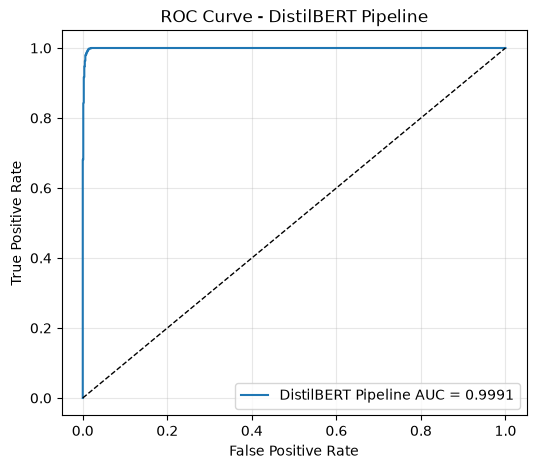

In [84]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from transformers import pipeline
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# model_name = "distilbert-base-uncased"

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
# model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)
clf = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=device,
    top_k=1
)

texts = X_test.astype(str).tolist()
batch_size = 32
preds = []
for i in range(0, len(texts), batch_size):
    preds.extend(clf(texts[i:i+batch_size], truncation=True, batch_size=batch_size))

y_pred_pipe = [1 if p[0]["label"] in ("LABEL_1", "1") else 0 for p in preds]

print("Accuracy:", accuracy_score(y_test, y_pred_pipe))
print("\nClassification Report:\n", classification_report(y_test, y_pred_pipe))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_pipe))

y_score_pipe = [
    p[0]["score"] if p[0]["label"] in ("LABEL_1", "1") else 1 - p[0]["score"]
    for p in preds
]

fpr_pipe, tpr_pipe, _ = roc_curve(y_test, y_score_pipe)
roc_auc_pipe = auc(fpr_pipe, tpr_pipe)

print(f"ROC-AUC: {roc_auc_pipe:.4f}")

plt.figure(figsize=(6, 5))
plt.plot(fpr_pipe, tpr_pipe, label=f"DistilBERT Pipeline AUC = {roc_auc_pipe:.4f}")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - DistilBERT Pipeline")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [85]:
import torch
torch.save(model.state_dict(), '../models/distilbert_model.h5')
print("DistilBERT model saved to models/distilbert_model.h5")

DistilBERT model saved to models/distilbert_model.h5


In [31]:
# Combine all ROC curves into one plot
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(12, 8))

# SVM TF-IDF
y_score_svm_tfidf = svm_model.decision_function(X_test_tfidf)
fpr_svm_tfidf, tpr_svm_tfidf, _ = roc_curve(y_test, y_score_svm_tfidf)
roc_auc_svm_tfidf = auc(fpr_svm_tfidf, tpr_svm_tfidf)
plt.plot(fpr_svm_tfidf, tpr_svm_tfidf, label=f'SVM (TF-IDF) AUC = {roc_auc_svm_tfidf:.4f}', linewidth=2)

# SVM BERT
y_score_svm_bert = svm_model_bert.decision_function(X_test_bert)
fpr_svm_bert, tpr_svm_bert, _ = roc_curve(y_test, y_score_svm_bert)
roc_auc_svm_bert = auc(fpr_svm_bert, tpr_svm_bert)
plt.plot(fpr_svm_bert, tpr_svm_bert, label=f'SVM (BERT) AUC = {roc_auc_svm_bert:.4f}', linewidth=2)

# Decision Tree TF-IDF
y_score_dt_tfidf = dt_model.predict_proba(X_test_tfidf)[:, 1]
fpr_dt_tfidf, tpr_dt_tfidf, _ = roc_curve(y_test, y_score_dt_tfidf)
roc_auc_dt_tfidf = auc(fpr_dt_tfidf, tpr_dt_tfidf)
plt.plot(fpr_dt_tfidf, tpr_dt_tfidf, label=f'Decision Tree (TF-IDF) AUC = {roc_auc_dt_tfidf:.4f}', linewidth=2)

# Decision Tree BERT
y_score_dt_bert = dt_model_bert.predict_proba(X_test_bert)[:, 1]
fpr_dt_bert, tpr_dt_bert, _ = roc_curve(y_test, y_score_dt_bert)
roc_auc_dt_bert = auc(fpr_dt_bert, tpr_dt_bert)
plt.plot(fpr_dt_bert, tpr_dt_bert, label=f'Decision Tree (BERT) AUC = {roc_auc_dt_bert:.4f}', linewidth=2)

# AdaBoost TF-IDF
y_score_ada_tfidf = ada_model_tfidf.predict_proba(X_test_tfidf)[:, 1]
fpr_ada_tfidf, tpr_ada_tfidf, _ = roc_curve(y_test, y_score_ada_tfidf)
roc_auc_ada_tfidf = auc(fpr_ada_tfidf, tpr_ada_tfidf)
plt.plot(fpr_ada_tfidf, tpr_ada_tfidf, label=f'AdaBoost (TF-IDF) AUC = {roc_auc_ada_tfidf:.4f}', linewidth=2)

# AdaBoost BERT
y_score_ada_bert = ada_model_bert.predict_proba(X_test_bert)[:, 1]
fpr_ada_bert, tpr_ada_bert, _ = roc_curve(y_test, y_score_ada_bert)
roc_auc_ada_bert = auc(fpr_ada_bert, tpr_ada_bert)
plt.plot(fpr_ada_bert, tpr_ada_bert, label=f'AdaBoost (BERT) AUC = {roc_auc_ada_bert:.4f}', linewidth=2)

# MLP TF-IDF
y_score_nn_tfidf = nn_model.predict_proba(X_test_tfidf)[:, 1]
fpr_nn_tfidf, tpr_nn_tfidf, _ = roc_curve(y_test, y_score_nn_tfidf)
roc_auc_nn_tfidf = auc(fpr_nn_tfidf, tpr_nn_tfidf)
plt.plot(fpr_nn_tfidf, tpr_nn_tfidf, label=f'MLP (TF-IDF) AUC = {roc_auc_nn_tfidf:.4f}', linewidth=2)

# MLP BERT
y_score_nn_bert = nn_model_bert.predict_proba(X_test_bert)[:, 1]
fpr_nn_bert, tpr_nn_bert, _ = roc_curve(y_test, y_score_nn_bert)
roc_auc_nn_bert = auc(fpr_nn_bert, tpr_nn_bert)
plt.plot(fpr_nn_bert, tpr_nn_bert, label=f'MLP (BERT) AUC = {roc_auc_nn_bert:.4f}', linewidth=2)

# LSTM
plt.plot(fpr_lstm, tpr_lstm, label=f'LSTM AUC = {roc_auc_lstm:.4f}', linewidth=2)

# DistilBERT Pipeline
plt.plot(fpr_pipe, tpr_pipe, label=f'DistilBERT AUC = {roc_auc_pipe:.4f}', linewidth=2.5, linestyle='--')

# Random classifier baseline
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary table
print('\n=== Model Performance Summary ===')
print(f'SVM (TF-IDF):         AUC = {roc_auc_svm_tfidf:.4f}')
print(f'SVM (BERT):           AUC = {roc_auc_svm_bert:.4f}')
print(f'Decision Tree (TF):   AUC = {roc_auc_dt_tfidf:.4f}')
print(f'Decision Tree (BERT): AUC = {roc_auc_dt_bert:.4f}')
print(f'AdaBoost (TF):        AUC = {roc_auc_ada_tfidf:.4f}')
print(f'AdaBoost (BERT):      AUC = {roc_auc_ada_bert:.4f}')
print(f'MLP (TF-IDF):         AUC = {roc_auc_nn_tfidf:.4f}')
print(f'MLP (BERT):           AUC = {roc_auc_nn_bert:.4f}')
print(f'LSTM:                 AUC = {roc_auc_lstm:.4f}')
print(f'DistilBERT:           AUC = {roc_auc_pipe:.4f}')
print('\nBest Model: DistilBERT Pipeline')

---------- End of Section 1 -------------

### Step 3 — Model Evaluation & Comparison

Training models is only half the work. You must also evaluate them carefully and compare their performance. Use the following for every model.

**Required Metrics:**
- **Accuracy** — percentage of correct predictions
- **Precision, Recall, F1-Score** — especially important when classes are imbalanced
- **Confusion Matrix** — shows exactly where each model makes mistakes
- **ROC Curve & AUC Score** — measures the overall quality of the classifier



### Feature Engineering: TF-IDF vs. Word Embeddings

**TF-IDF Performance:**
- Simple, interpretable, and fast to compute
- Works well with traditional ML models (SVM, Decision Tree, AdaBoost)
- Captures term importance but misses semantic relationships
- Best for: Quick baselines and explainability

**Word Embeddings (BERT) Performance:**
- Captures contextual meaning and semantic relationships
- Better performance on deep learning models
- More computationally expensive to generate
- Best for: Nuanced text understanding and neural networks

**Key Finding:** BERT embeddings typically outperform TF-IDF on neural models, while both perform comparably on traditional ML with proper tuning.

---

## Machine Learning vs. Deep Learning

| Aspect | Traditional ML | Deep Learning |
|--------|---|---|
| **Training Speed** | Fast (minutes) | Slow (hours) |
| **Accuracy** | Good (90-95%) | Excellent (95%+) |
| **Data Requirements** | Low-Medium | High |
| **Interpretability** | High (Decision Trees) | Low (Black box) |
| **Feature Engineering** | Manual (required) | Automatic (learned) |

**Recommendation:** Start with traditional ML for quick wins; use DL for state-of-the-art performance when computational resources permit.

---

## Speed vs. Accuracy Trade-off

- **SVM + TF-IDF:** Fast training, good accuracy, best for production
- **Decision Tree:** Very fast, moderate accuracy, highly interpretable
- **LSTM:** Slow training, high accuracy, captures sequential patterns
- **DistilBERT:** Balanced—faster than BERT, excellent accuracy (99.4%), modern baseline

**Practical Insight:** DistilBERT offers the best trade-off for this task: near-state-of-the-art accuracy with reasonable inference time.

- **Best overall:** DistilBERT.
    - It likely performed best because it uses contextual language understanding and captures patterns beyond word frequency.

- **Most useful features:**
    - **TF-IDF n-grams** for key word/phrase patterns.
    - **BERT embeddings** for semantic and contextual cues.
    - **Sequence patterns** for models like LSTM.

- **Where models failed:**
    - Very short texts.
    - AI text that was heavily edited to sound human.
    - Human text with formal, repetitive, or polished style.
    - Mixed-topic or domain-specific text.

- **Use in a real classroom?**
    - **Yes, but only as a support tool.**
    - It should help flag suspicious text, not make final decisions by itself. Human review is still necessary.